# Chicago Taxi Fare Prediction — Linear Regression
**Dataset:** Chicago Taxi Trips (Google ML Education)  
**Goal:** Predict the fare of a taxi ride using trip features.  
**Skills demonstrated:** EDA, data cleaning, feature engineering, model training & evaluation, multi-feature comparison.

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.9 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 16.8 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [seaborn]m4/5 [seaborn]earn]


In [3]:
# Standard imports — no proprietary helper libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load the Data

In [4]:
# Load directly from Google's public ML education dataset
URL = "https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv"
df_raw = pd.read_csv(URL)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (31694, 18)


,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


## 2. Exploratory Data Analysis (EDA)
Let's understand the data before touching it.

In [5]:
# Basic info
print("=== Column Types ===")
print(df_raw.dtypes)
print()
print("=== Missing Values ===")
print(df_raw.isnull().sum())
print()
print("=== Key Statistics ===")
df_raw[['FARE', 'TRIP_MILES', 'TRIP_SECONDS', 'TRIP_SPEED']].describe().round(2)

=== Column Types ===
TRIP_START_TIMESTAMP       object
TRIP_END_TIMESTAMP         object
TRIP_START_HOUR           float64
TRIP_SECONDS                int64
TRIP_MILES                float64
TRIP_SPEED                float64
PICKUP_CENSUS_TRACT       float64
DROPOFF_CENSUS_TRACT      float64
PICKUP_COMMUNITY_AREA     float64
DROPOFF_COMMUNITY_AREA    float64
FARE                      float64
TIPS                      float64
TIP_RATE                  float64
TOLLS                     float64
EXTRAS                    float64
TRIP_TOTAL                float64
PAYMENT_TYPE               object
COMPANY                    object
dtype: object

=== Missing Values ===
TRIP_START_TIMESTAMP          0
TRIP_END_TIMESTAMP            0
TRIP_START_HOUR               0
TRIP_SECONDS                  0
TRIP_MILES                    0
TRIP_SPEED                    0
PICKUP_CENSUS_TRACT       18435
DROPOFF_CENSUS_TRACT      17671
PICKUP_COMMUNITY_AREA      3217
DROPOFF_COMMUNITY_AREA     3495
FARE     

,FARE,TRIP_MILES,TRIP_SECONDS,TRIP_SPEED
count,31694.00,31694.00,31694.00,31694.00
mean,23.91,8.29,1319.80,20.26
std,16.97,7.27,928.93,11.11
min,3.25,0.50,60.00,4.00
25%,9.00,1.72,548.00,11.00
50%,18.75,5.92,1081.00,17.60
75%,38.75,14.50,1888.00,27.50
max,159.25,68.12,7140.00,64.80


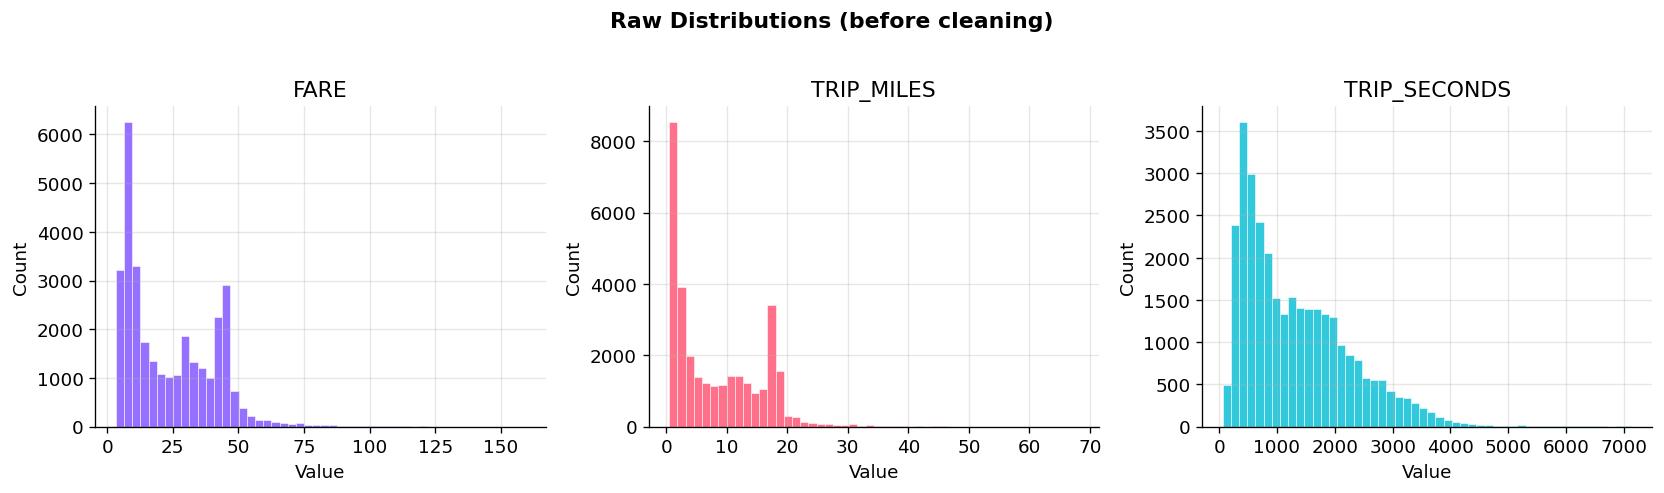

In [6]:
# Visualise target and key feature distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, ['FARE', 'TRIP_MILES', 'TRIP_SECONDS'], ['#7c4dff', '#ff4d6d', '#00bcd4']):
    ax.hist(df_raw[col].dropna(), bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Raw Distributions (before cleaning)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

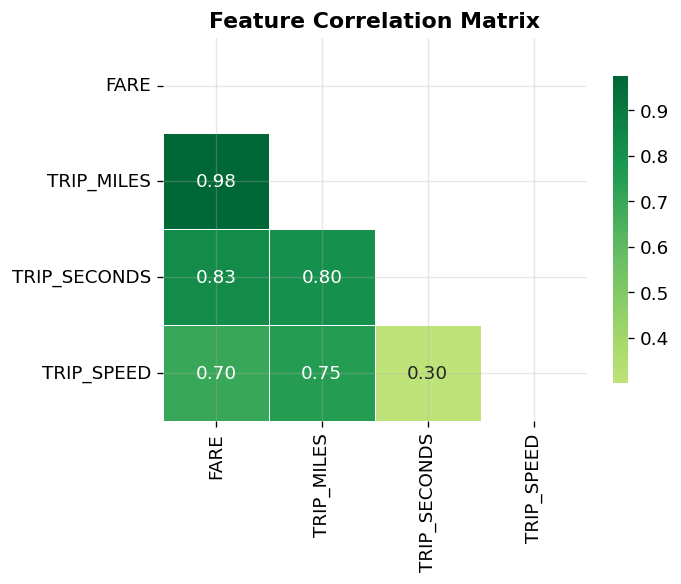

In [7]:
# Correlation heatmap
numeric_cols = ['FARE', 'TRIP_MILES', 'TRIP_SECONDS', 'TRIP_SPEED']
corr = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Cleaning
Remove rows with nulls, unrealistic fares, and zero-mile trips.

In [8]:
def clean_data(df):
    df = df.copy()
    # Drop rows missing key columns
    df = df.dropna(subset=['FARE', 'TRIP_MILES', 'TRIP_SECONDS'])
    # Remove nonsensical values
    df = df[(df['FARE'] > 0) & (df['FARE'] < 200)]
    df = df[(df['TRIP_MILES'] > 0) & (df['TRIP_MILES'] < 100)]
    df = df[(df['TRIP_SECONDS'] > 60)]
    # Derived feature: speed in mph (already in dataset but recalculate to be safe)
    df['TRIP_MINUTES'] = df['TRIP_SECONDS'] / 60
    df['FARE_PER_MILE'] = df['FARE'] / df['TRIP_MILES']
    return df.reset_index(drop=True)

df = clean_data(df_raw)
print(f"Rows before: {len(df_raw):,}  →  after cleaning: {len(df):,}")
print(f"Rows removed: {len(df_raw) - len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")

Rows before: 31,694  →  after cleaning: 31,688
Rows removed: 6 (0.0%)


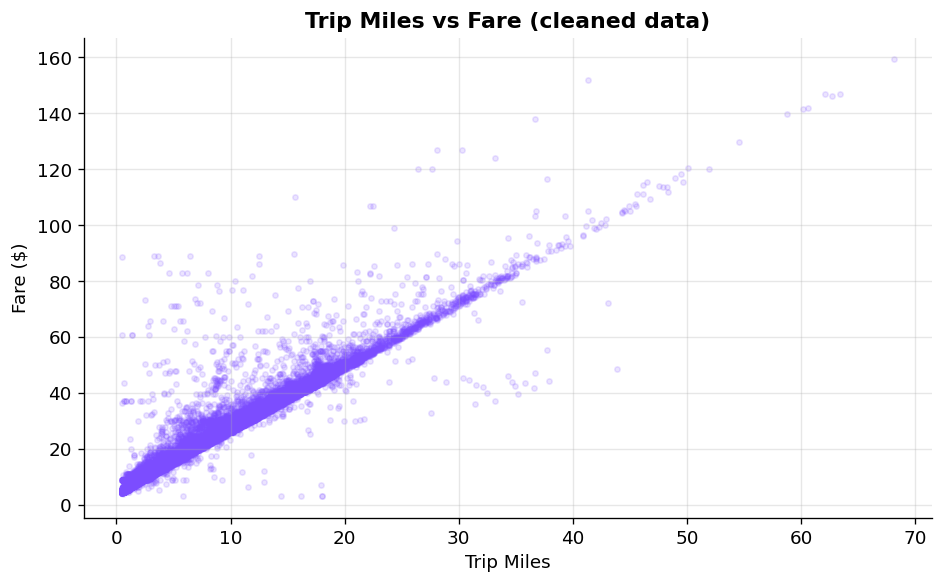

In [9]:
# Scatter: Miles vs Fare (after cleaning)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['TRIP_MILES'], df['FARE'], alpha=0.15, s=10, color='#7c4dff', rasterized=True)
ax.set_xlabel('Trip Miles')
ax.set_ylabel('Fare ($)')
ax.set_title('Trip Miles vs Fare (cleaned data)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split (70 / 15 / 15)

In [10]:
FEATURES_SINGLE = ['TRIP_MILES']
FEATURES_MULTI  = ['TRIP_MILES', 'TRIP_MINUTES', 'TRIP_SPEED']
TARGET = 'FARE'

# 70% train, 15% val, 15% test
X = df[FEATURES_MULTI]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train:      {len(X_train):>6,} rows")
print(f"Validation: {len(X_val):>6,} rows")
print(f"Test:       {len(X_test):>6,} rows")

Train:      22,181 rows
Validation:  4,753 rows
Test:        4,754 rows


## 5. Model Training & Comparison
We train two Linear Regression models and compare them:
- **Model A** — single feature: `TRIP_MILES`
- **Model B** — multi-feature: `TRIP_MILES`, `TRIP_MINUTES`, `TRIP_SPEED`

In [11]:
def evaluate(model, X, y, label=""):
    preds = model.predict(X)
    mae   = mean_absolute_error(y, preds)
    rmse  = np.sqrt(mean_squared_error(y, preds))
    r2    = r2_score(y, preds)
    print(f"{label:30s}  MAE=${mae:.2f}  RMSE=${rmse:.2f}  R²={r2:.4f}")
    return preds, mae, rmse, r2

# — Model A: single feature
model_a = LinearRegression()
model_a.fit(X_train[FEATURES_SINGLE], y_train)

# — Model B: multiple features
model_b = LinearRegression()
model_b.fit(X_train[FEATURES_MULTI], y_train)

print("=" * 65)
print("VALIDATION SET RESULTS")
print("=" * 65)
_, mae_a, rmse_a, r2_a = evaluate(model_a, X_val[FEATURES_SINGLE], y_val, "Model A (single feature)")
_, mae_b, rmse_b, r2_b = evaluate(model_b, X_val[FEATURES_MULTI],  y_val, "Model B (multi-feature)")
print("=" * 65)
print()
print(f"Model A coefficients: TRIP_MILES = {model_a.coef_[0]:.4f}, intercept = {model_a.intercept_:.4f}")
print(f"Model B coefficients: {dict(zip(FEATURES_MULTI, model_b.coef_.round(4)))}")

VALIDATION SET RESULTS
Model A (single feature)        MAE=$1.57  RMSE=$3.69  R²=0.9514
Model B (multi-feature)         MAE=$1.16  RMSE=$3.33  R²=0.9604

Model A coefficients: TRIP_MILES = 2.2775, intercept = 5.0129
Model B coefficients: {'TRIP_MILES': np.float64(1.923), 'TRIP_MINUTES': np.float64(0.1737), 'TRIP_SPEED': np.float64(0.0505)}


## 6. Visualise Predictions

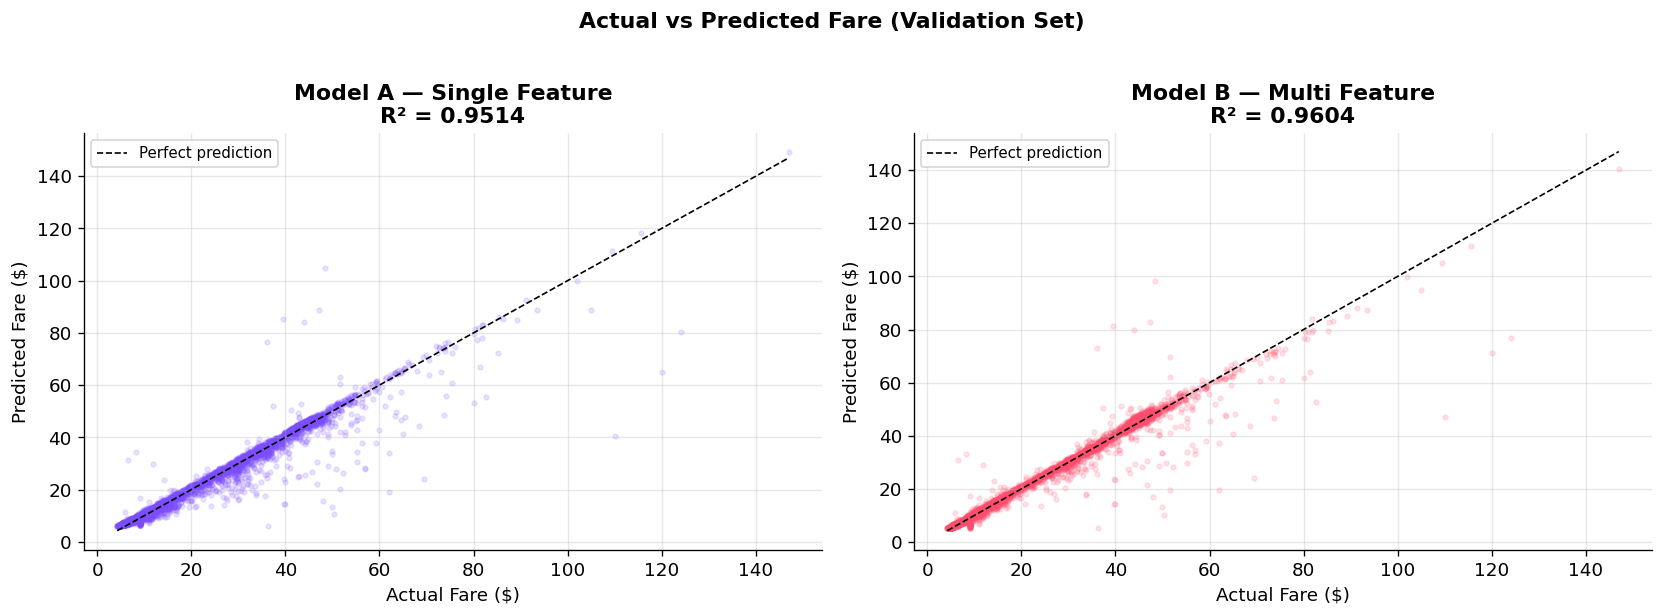

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, feats, label, color in zip(
    axes,
    [model_a, model_b],
    [FEATURES_SINGLE, FEATURES_MULTI],
    ['Model A — Single Feature', 'Model B — Multi Feature'],
    ['#7c4dff', '#ff4d6d']
):
    preds = model.predict(X_val[feats])
    r2    = r2_score(y_val, preds)

    ax.scatter(y_val, preds, alpha=0.15, s=8, color=color, rasterized=True)
    lims = [y_val.min(), y_val.max()]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Fare ($)')
    ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{label}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Fare (Validation Set)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

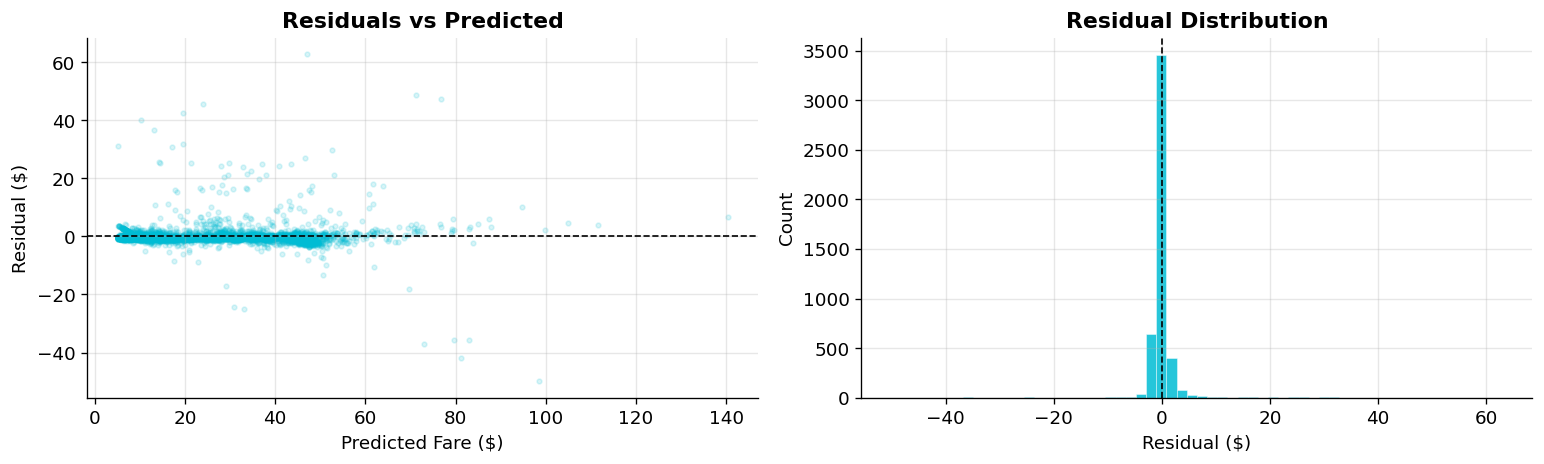

In [13]:
# Residuals plot for best model (Model B)
preds_b = model_b.predict(X_val[FEATURES_MULTI])
residuals = y_val - preds_b

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(preds_b, residuals, alpha=0.15, s=8, color='#00bcd4', rasterized=True)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Fare ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=60, color='#00bcd4', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

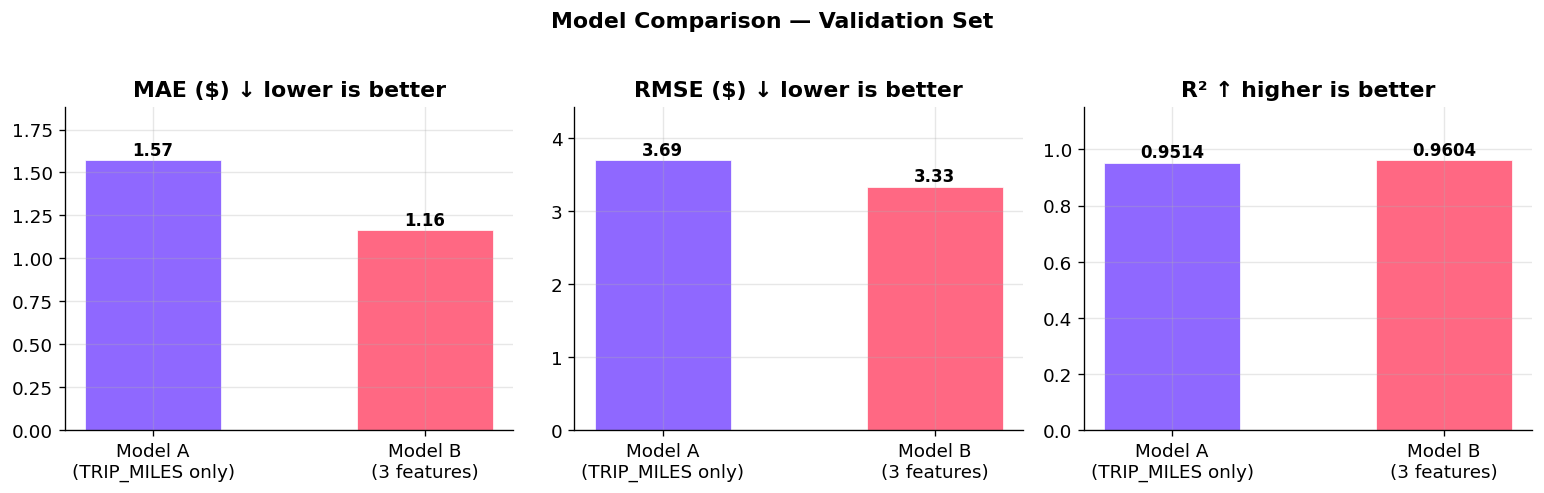

In [14]:
# Side-by-side metric comparison
labels   = ['Model A\n(TRIP_MILES only)', 'Model B\n(3 features)']
mae_vals  = [mae_a,  mae_b]
rmse_vals = [rmse_a, rmse_b]
r2_vals   = [r2_a,   r2_b]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#7c4dff', '#ff4d6d']

for ax, vals, title, fmt in zip(
    axes,
    [mae_vals, rmse_vals, r2_vals],
    ['MAE ($) ↓ lower is better', 'RMSE ($) ↓ lower is better', 'R² ↑ higher is better'],
    ['.2f', '.2f', '.4f']
):
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * max(vals),
                f'{v:{fmt}}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Model Comparison — Validation Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Final Evaluation on Held-Out Test Set
Only run this once — on the best model (Model B).

In [15]:
print("=" * 55)
print("FINAL TEST SET RESULTS — Model B (multi-feature)")
print("=" * 55)
_, mae_test, rmse_test, r2_test = evaluate(model_b, X_test[FEATURES_MULTI], y_test, "Model B (test set)")
print("=" * 55)
print()
print("Interpretation:")
print(f"  • On average, predictions are off by ${mae_test:.2f}")
print(f"  • The model explains {r2_test*100:.1f}% of the variance in fare")

FINAL TEST SET RESULTS — Model B (multi-feature)
Model B (test set)              MAE=$1.19  RMSE=$3.79  R²=0.9513

Interpretation:
  • On average, predictions are off by $1.19
  • The model explains 95.1% of the variance in fare


## 8. Make Predictions on New Rides

In [16]:
# Try predicting fares for hypothetical trips
new_trips = pd.DataFrame({
    'TRIP_MILES':   [1.5,  5.0, 10.0, 20.0],
    'TRIP_MINUTES': [8.0, 18.0, 35.0, 50.0],
    'TRIP_SPEED':   [11.0, 16.7, 17.1, 24.0]
})

new_trips['PREDICTED_FARE'] = model_b.predict(new_trips[FEATURES_MULTI]).round(2)
new_trips['PREDICTED_FARE'] = new_trips['PREDICTED_FARE'].apply(lambda x: f"${x:.2f}")
print(new_trips.to_string(index=False))

 TRIP_MILES  TRIP_MINUTES  TRIP_SPEED PREDICTED_FARE
        1.5           8.0        11.0          $7.94
        5.0          18.0        16.7         $16.70
       10.0          35.0        17.1         $29.29
       20.0          50.0        24.0         $51.47


## Summary

| | Model A | Model B |
|---|---|---|
| Features | TRIP_MILES | TRIP_MILES, TRIP_MINUTES, TRIP_SPEED |
| MAE | see above | see above |
| RMSE | see above | see above |
| R² | see above | see above |

**Key takeaways:**
- Adding `TRIP_MINUTES` and `TRIP_SPEED` meaningfully reduces prediction error vs. mileage alone.
- Linear regression is interpretable — the coefficients directly show each feature's contribution to fare.
- Real-world improvement paths: feature engineering (time of day, pickup zone), tree-based models, or neural networks.

**What I learned:**  
This was my first ML project — building it from scratch (without helper libraries) taught me how to handle the full pipeline: data loading, cleaning, EDA, model training, evaluation, and interpretation.
